# Financial Sentiment and the S&P 500: Exploratory Data Analysis

Notebook 1 of 7 in a chained Kaggle pipeline: EDA, data and baseline, FinBERT fine-tuning, evaluation, headline scoring, the market model, and the serving export. This notebook studies the three raw sources and checks the facts the later notebooks rely on. Nothing it computes is read downstream.

The sources are the Financial PhraseBank (Malo et al. 2014), Reuters headlines collected in the Kaggle dataset `notlucasp/financial-news-headlines`, and daily S&P 500 index prices from Yahoo Finance in the Kaggle dataset `paveljurke/s-and-p-500-gspc-historical-data`.

## Setup

Imports, plotting style and helpers. `find_file` searches the Kaggle inputs so the notebook does not depend on how Kaggle mounts each dataset, `save` writes every figure to `figures/`, and `read_subset` parses one PhraseBank file, whose lines have the form `sentence@label`; it tries UTF-8 and falls back to Latin-1. `SMOKE` exists for the pipeline runner; this notebook is light enough to run in full either way.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from scipy.stats import binomtest

SMOKE = False
SEED = 42
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
CLASS_COLORS = {"negative": "#eb6834", "neutral": "#898781", "positive": "#1baf7a"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
LABELS = ["negative", "neutral", "positive"]
SUBSETS = {50: "Sentences_50Agree.txt", 66: "Sentences_66Agree.txt", 75: "Sentences_75Agree.txt", 100: "Sentences_AllAgree.txt"}
PB_SOURCE = "Financial PhraseBank v1.0 (Malo et al. 2014), CC BY-NC-SA 3.0"
RT_SOURCE = "Reuters headlines via the Kaggle dataset notlucasp/financial-news-headlines"
HISTORY, INITIAL = 20, 200
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


def read_text(path):
    raw = path.read_bytes()
    try:
        return raw.decode("utf-8"), "utf-8"
    except UnicodeDecodeError:
        return raw.decode("latin-1"), "latin-1"


def read_subset(level):
    text, encoding = read_text(find_file(SUBSETS[level]))
    rows = []
    for line in text.splitlines():
        if line.strip():
            sentence, _, label = line.strip().rpartition("@")
            rows.append((sentence.strip(), label.strip()))
    return pd.DataFrame(rows, columns=["sentence", "label"]), encoding


print(f"smoke={SMOKE}")
print(f"pandas {pd.__version__}, numpy {np.__version__}")

smoke=False
pandas 2.3.3, numpy 2.1.3


**Conclusion.** The smoke switch is off, so this run reads the full data. Kaggle's image provides pandas 2.3.3 and NumPy 2.1.3; nothing is installed for this notebook or for notebook 2.

## Financial PhraseBank: the four agreement subsets

Each sentence was labelled by 5 to 8 annotators; the dataset ships four files holding the sentences on which at least 50%, 66%, 75% or all annotators agreed. This cell reads all four and prints line counts, the file encoding and label shares. The aim is to confirm the sizes the design relies on (about 4,846 sentences at 50%) and to see how the label mix shifts as agreement rises.

In [2]:
subsets, encodings = {}, {}
for level in SUBSETS:
    subsets[level], encodings[level] = read_subset(level)
for level, frame in subsets.items():
    shares = frame["label"].value_counts(normalize=True).reindex(LABELS)
    print(f"{level}% agreement: {len(frame):,} lines, encoding {encodings[level]}, label values {sorted(frame['label'].unique())}, "
          + ", ".join(f"{label} {shares[label]:.1%}" for label in LABELS))

50% agreement: 4,846 lines, encoding latin-1, label values ['negative', 'neutral', 'positive'], negative 12.5%, neutral 59.4%, positive 28.1%
66% agreement: 4,217 lines, encoding latin-1, label values ['negative', 'neutral', 'positive'], negative 12.2%, neutral 60.1%, positive 27.7%
75% agreement: 3,453 lines, encoding latin-1, label values ['negative', 'neutral', 'positive'], negative 12.2%, neutral 62.1%, positive 25.7%
100% agreement: 2,264 lines, encoding latin-1, label values ['negative', 'neutral', 'positive'], negative 13.4%, neutral 61.4%, positive 25.2%


**Conclusion.** The four files hold 4,846, 4,217, 3,453 and 2,264 lines, the published sizes. All four are Latin-1 encoded rather than UTF-8, so the reader's fallback is needed, and the label values are exactly negative, neutral and positive. Neutral dominates every subset (59.4% at 50% agreement, 61.4% at 100%), and the positive share falls from 28.1% to 25.2% as agreement rises.

## Nesting, duplicates and conflicting labels

The design assigns each sentence the highest agreement level whose file contains it, which is only sound if the files are nested (every 100% sentence also sits in the 75% file with the same label, and so on). This cell checks the nesting, then counts sentences that appear on more than one line of the 50% file and those whose copies disagree on the label. Notebook 2 collapses repeated sentences with one label and drops conflicting ones, so the counts here tell how many sentences that leaves.

In [3]:
pairs = {level: set(zip(frame["sentence"], frame["label"])) for level, frame in subsets.items()}
levels = sorted(SUBSETS)
for lower, upper in zip(levels, levels[1:]):
    print(f"pairs in the {upper}% file missing from the {lower}% file: {len(pairs[upper] - pairs[lower])}")
base = subsets[50]
stats = base.groupby("sentence")["label"].agg(["size", "nunique"])
repeated = stats[stats["size"] > 1]
conflicted = stats[stats["nunique"] > 1]
print(f"distinct sentences in the 50% file: {len(stats):,} of {len(base):,} lines")
print(f"sentences on more than one line: {len(repeated)} ({int(repeated['size'].sum())} lines)")
print(f"sentences with conflicting labels: {len(conflicted)} ({int(conflicted['size'].sum())} lines)")
kept = base[~base["sentence"].isin(conflicted.index)].drop_duplicates("sentence").reset_index(drop=True)
agreement = pd.Series([max(level for level in levels if (s, l) in pairs[level]) for s, l in zip(kept["sentence"], kept["label"])])
print(f"sentences kept after collapsing duplicates and dropping conflicts: {len(kept):,}")
print("kept sentences by highest agreement level: " + ", ".join(f"{level}% {count}" for level, count in agreement.value_counts().sort_index().items()))
print("kept sentences by label: " + ", ".join(f"{label} {count}" for label, count in kept["label"].value_counts().reindex(LABELS).items()))

pairs in the 66% file missing from the 50% file: 0
pairs in the 75% file missing from the 66% file: 0
pairs in the 100% file missing from the 75% file: 0
distinct sentences in the 50% file: 4,838 of 4,846 lines
sentences on more than one line: 8 (16 lines)
sentences with conflicting labels: 2 (4 lines)
sentences kept after collapsing duplicates and dropping conflicts: 4,836
kept sentences by highest agreement level: 50% 627, 66% 761, 75% 1189, 100% 2259
kept sentences by label: negative 604, neutral 2871, positive 1361


**Conclusion.** No pair in a higher-agreement file is missing from the next lower one, so the files are nested and the highest file holding a sentence is a well-defined agreement level. The 50% file has 4,838 distinct sentences on 4,846 lines: 8 sentences appear twice and 2 of them carry different labels on their two lines. Dropping those 2 and collapsing the other repeats leaves 4,836 sentences, which keeps the 4.8K figure. Most kept sentences are easy ones: 2,259 have 100% agreement, 1,189 reach 75%, 761 reach 66% and only 627 sit at the 50% level. Kept labels: 604 negative, 2,871 neutral, 1,361 positive.

## Sentence length and label mix

Sentence length decides the tokeniser limit in notebook 3 (128 tokens is planned), and the label mix decides how much accuracy a constant guess would get. This cell summarises words per kept sentence and draws the label shares of each subset next to the length histogram.

count    4836.0
mean       23.1
std         9.9
min         2.0
50%        21.0
90%        37.0
99%        50.0
max        81.0
accuracy of always predicting the majority class on the kept sentences: 0.5937


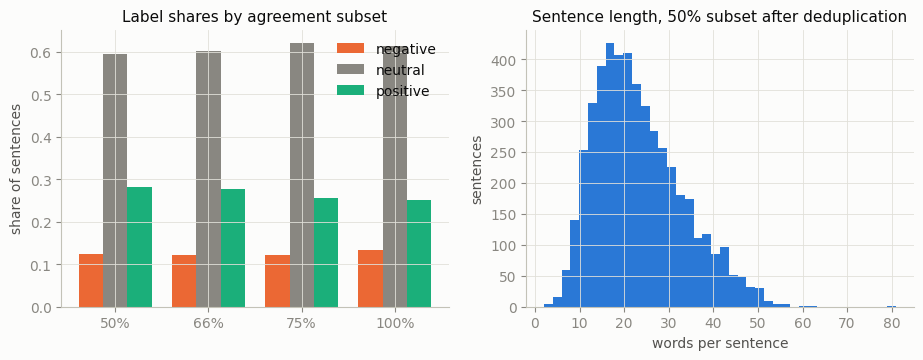

In [4]:
words = kept["sentence"].str.split().str.len()
print(words.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())
print(f"accuracy of always predicting the majority class on the kept sentences: {kept['label'].value_counts(normalize=True).max():.4f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
x = np.arange(len(levels))
for i, label in enumerate(LABELS):
    shares = [subsets[level]["label"].value_counts(normalize=True).get(label, 0.0) for level in levels]
    axes[0].bar(x + (i - 1) * 0.26, shares, width=0.26, color=CLASS_COLORS[label], label=label)
axes[0].set_xticks(x, [f"{level}%" for level in levels])
axes[0].set_ylabel("share of sentences")
axes[0].set_title("Label shares by agreement subset")
axes[0].legend()
axes[1].hist(words, bins=40, color=SERIES[0])
axes[1].set_xlabel("words per sentence")
axes[1].set_ylabel("sentences")
axes[1].set_title("Sentence length, 50% subset after deduplication")
save(fig, "phrasebank_overview")

**Conclusion.** Sentences average 23.1 words with a median of 21, a 99th percentile of 50 and a maximum of 81, so nearly all should fit in 128 tokens even after subword splitting; notebook 3 measures this in tokens. Always predicting neutral scores 59.37%, the floor any model must clear. The figure shows the label mix barely moving across subsets and a right-skewed length distribution.

## Five example sentences

A handful of sentences, drawn with a fixed seed, show what the annotators labelled. The licence (CC BY-NC-SA 3.0) allows non-commercial sharing with attribution; the project shows at most five rows per dataset.

In [5]:
rng = np.random.default_rng(SEED)
for i in sorted(rng.choice(len(kept), size=5, replace=False)):
    print(f"[{kept.loc[i, 'label']}] {kept.loc[i, 'sentence']}")
print(f"source: {PB_SOURCE}")

[positive] In September 2010 , the Finnish group agreed to buy Danish company Rose Poultry A-S for up to EUR23 .9 m in a combination of cash and stock .
[positive] Finnish financial software developer Basware Oyj said today it will provide its invoice automation ( IA ) solution to an unnamed major retail company in the USA in a deal , worth more than EUR300 ,000 .
[positive] in Q1 2010 18 May 2010 - Finnish electrical components maker Salcomp Oy ( HEL : SAL1V ) said today it turned to a net profit of EUR1 .6 m in the first quarter of 2010 versus a loss of EUR2m in the corresponding period last year .
[neutral] The business units of the InvestLesProm Group cover the full forest industry chain , and the Group owns forests , sawmills , paper and pulp mills , and other processing plants .
[positive] Strand Associates is expanding its Madison corporate headquarters with space to add about 100 employees to the engineering firm .
source: Financial PhraseBank v1.0 (Malo et al. 2014), CC BY-NC-

**Conclusion.** Five sentences drawn with seed 42, four positive and one neutral, show the PhraseBank's character: news about Finnish companies in press-release style, with tokenisation artefacts such as `EUR23 .9 m` and spaces before punctuation that the tokenizer has to absorb.

## Reuters headlines: rows, dates and duplicates

The headline file has the columns `Headlines`, `Time` and `Description`; `Time` is a date without a time of day. This cell parses the dates with the format seen on the dataset page (for example `Jul 18 2020`), reports anything that fails to parse, and counts exact duplicates and repeated headline and date pairs, which notebook 5 drops.

In [6]:
heads = pd.read_csv(find_file("reuters_headlines.csv"))
print(f"columns: {list(heads.columns)}, rows {len(heads):,}")
heads["date"] = pd.to_datetime(heads["Time"].astype(str).str.strip(), format="%b %d %Y", errors="coerce")
print(f"unparseable dates: {int(heads['date'].isna().sum())}")
print(f"date range: {heads['date'].min().date()} to {heads['date'].max().date()}")
print(f"exact duplicate rows: {int(heads.duplicated().sum())}")
print(f"repeated headline and date pairs: {int(heads.duplicated(['Headlines', 'date']).sum())}")
clean = heads.dropna(subset=["date"]).drop_duplicates(["Headlines", "date"]).reset_index(drop=True)
print(f"headlines after dropping repeats: {len(clean):,}, distinct headline texts {clean['Headlines'].nunique():,}")
print(clean["Headlines"].str.split().str.len().describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

columns: ['Headlines', 'Time', 'Description'], rows 32,770
unparseable dates: 0
date range: 2018-03-20 to 2020-07-18
exact duplicate rows: 55
repeated headline and date pairs: 78
headlines after dropping repeats: 32,692, distinct headline texts 32,575
count    32692.0
mean        10.3
std          1.9
min          3.0
50%         10.0
90%         13.0
99%         15.0
max         19.0


**Conclusion.** The file has 32,770 rows dated 2018-03-20 to 2020-07-18, and every date parses with the format `%b %d %Y`. 55 rows are exact duplicates and 78 repeat a headline on the same date; dropping those leaves 32,692 headlines, of which 32,575 texts are distinct (the rest recur on different dates). Headlines are short, 10.3 words on average and at most 19, so the 64-token limit in notebook 5 will cut almost nothing.

## Headline coverage over time

The market model aggregates headlines per trading session, so gaps in coverage would leave sessions without a signal. This cell counts headlines per calendar day over the whole range, reports days with none and the weekday pattern, and plots the daily count with a 20-day mean.

calendar days 852, days without headlines 0
headlines per day: mean 38.4, median 42, max 126
mean headlines by weekday: Mon 43.3, Tue 52.2, Wed 52.6, Thu 54.8, Fri 48.1, Sat 7.5, Sun 10.0


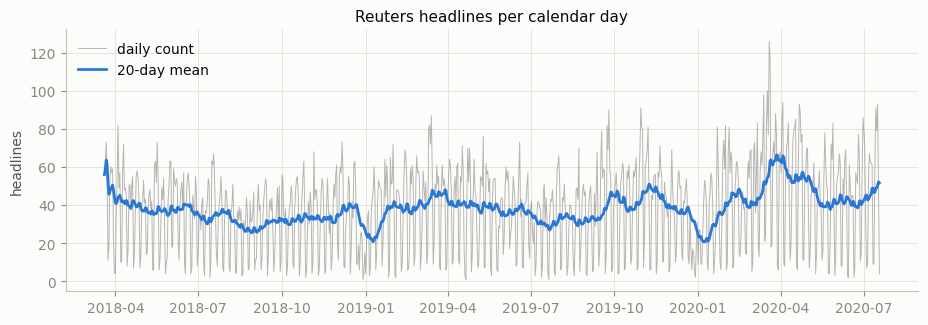

In [7]:
days = pd.date_range(clean["date"].min(), clean["date"].max(), freq="D")
per_day = clean.groupby("date").size().reindex(days, fill_value=0)
print(f"calendar days {len(days)}, days without headlines {int((per_day == 0).sum())}")
print(f"headlines per day: mean {per_day.mean():.1f}, median {per_day.median():.0f}, max {per_day.max()}")
weekday = per_day.groupby(per_day.index.dayofweek).mean()
print("mean headlines by weekday: " + ", ".join(f"{name} {weekday[i]:.1f}" for i, name in enumerate(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])))
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(per_day.index, per_day.values, color=MUTED, linewidth=0.7, alpha=0.6, label="daily count")
ax.plot(per_day.index, per_day.rolling(20, min_periods=1).mean(), color=SERIES[0], label="20-day mean")
ax.set_ylabel("headlines")
ax.set_title("Reuters headlines per calendar day")
ax.legend()
save(fig, "headlines_per_day")

**Conclusion.** All 852 calendar days have at least one headline, with a mean of 38.4 and a median of 42 per day. Weekdays average 43 to 55 headlines and weekends 7.5 to 10, which the session mapping folds into Monday's window. The figure shows a steady 30 to 50 headlines a day, dips over the year-end holidays and a surge to 126 a day in March 2020, when the COVID crash dominated the news.

## Five example headlines

Five headlines drawn with a fixed seed, with attribution. Headline text is Reuters' own, so the project never redistributes it beyond these examples; the app and the serving bundle carry only daily aggregates.

In [8]:
for i in sorted(rng.choice(len(clean), size=5, replace=False)):
    print(f"{clean.loc[i, 'date'].date()}  {clean.loc[i, 'Headlines']}")
print(f"source: {RT_SOURCE}")

2020-05-10  China central bank signals more policy measures to support virus-ravaged economy
2019-05-23  Oil plummets, on track for biggest weekly drop in 2019
2018-11-26  Bitcoin sinks as cryptocurrency sell-off gathers pace
2018-10-31  Honda and GAC Group to build $430 million Chinese plant for new-energy cars
2018-04-06  Levi Strauss sues LVMH's Kenzo over jeans pocket tab
source: Reuters headlines via the Kaggle dataset notlucasp/financial-news-headlines


**Conclusion.** Five headlines drawn with seed 42 span central bank policy, oil, crypto, a corporate investment and a lawsuit. Many are not about US equities at all, which is one reason aggregate headline sentiment may say little about the S&P 500's next session.

## S&P 500 prices

The market target is the open to close return of the next session, so the open price must be real. Older index data on Yahoo sometimes repeats the previous close as the open; this cell counts such sessions inside the headline range. It also summarises open to close and close to close returns there and the share of up sessions per year for both, which sets the rate an always-up guess would score.

columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], rows 24,805
price history: 1927-12-30 to 2026-10-01
sessions in the headline range: 591, opens equal to the previous close: 1
            oc       cc
count  591.000  591.000
mean     0.001    0.041
std      1.071    1.559
min     -5.710  -11.984
25%     -0.307   -0.394
50%      0.045    0.091
75%      0.444    0.663
max      5.488    9.383
      sessions  up_open_close  up_close_close
date                                         
2018       197          0.482           0.508
2019       252          0.583           0.595
2020       142          0.549           0.563


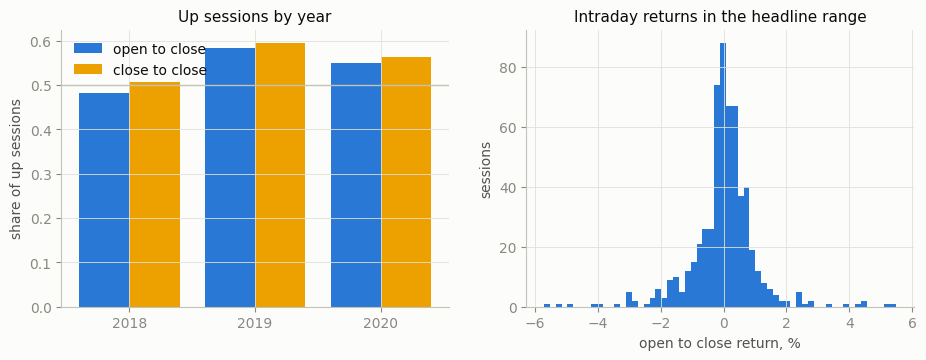

In [9]:
prices = pd.read_csv(find_file("sap500.csv"))
print(f"columns: {list(prices.columns)}, rows {len(prices):,}")
prices["date"] = pd.to_datetime(prices["Date"].astype(str).str[:10])
prices = prices.sort_values("date").drop_duplicates("date").reset_index(drop=True)
prices["oc"] = (prices["Close"] / prices["Open"] - 1) * 100
prices["cc"] = prices["Close"].pct_change() * 100
print(f"price history: {prices['date'].min().date()} to {prices['date'].max().date()}")
window = prices[(prices["date"] > clean["date"].min()) & (prices["date"] <= clean["date"].max() + pd.Timedelta(days=7))].copy()
repeat_open = np.isclose(window["Open"], prices["Close"].shift(1).loc[window.index])
print(f"sessions in the headline range: {len(window)}, opens equal to the previous close: {int(repeat_open.sum())}")
print(window[["oc", "cc"]].describe().round(3).to_string())
yearly = window.groupby(window["date"].dt.year).agg(sessions=("oc", "size"), up_open_close=("oc", lambda s: (s > 0).mean()), up_close_close=("cc", lambda s: (s > 0).mean()))
print(yearly.round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
years = yearly.index.astype(str)
x = np.arange(len(years))
axes[0].bar(x - 0.2, yearly["up_open_close"], width=0.4, color=SERIES[0], label="open to close")
axes[0].bar(x + 0.2, yearly["up_close_close"], width=0.4, color=SERIES[3], label="close to close")
axes[0].axhline(0.5, color=AXIS, linewidth=1)
axes[0].set_xticks(x, years)
axes[0].set_ylabel("share of up sessions")
axes[0].set_title("Up sessions by year")
axes[0].legend()
axes[1].hist(window["oc"], bins=60, color=SERIES[0])
axes[1].set_xlabel("open to close return, %")
axes[1].set_ylabel("sessions")
axes[1].set_title("Intraday returns in the headline range")
save(fig, "sp500_returns")

**Conclusion.** The price file covers 1927-12-30 to 2026-10-01 with the expected columns. The headline range has 591 sessions and only one open equal to the previous close, so the opens are real prices. The open to close return has a mean of 0.001% and a standard deviation of 1.07%, from -5.71% to +5.49%; close to close returns are wider (sd 1.56%). Up sessions by the open to close measure were 48.2% in 2018, 58.3% in 2019 and 54.9% in 2020 (close to close 50.8%, 59.5% and 56.3%), so always predicting up was a strong rule in 2019 and 2020. The histogram is sharply peaked at zero with fat tails.

## Sessions and statistical power

This cell applies notebook 6's mapping without looking at any target: a headline dated d feeds the first trading session strictly after d, and a session counts only when its whole window (from the previous session day to the day before it) lies inside the headline range. It prints how many sessions that gives, how many headlines feed them, how many sessions have none, the size of the walk-forward test after 20 history sessions and a 200-session initial window, and the accuracy a one-sided binomial test against 0.5 needs at that size to reach p < 0.01.

In [10]:
dates = prices["date"].to_numpy()
first, last = clean["date"].min(), clean["date"].max()
calendar = pd.DataFrame({"session": prices["date"], "prev": prices["date"].shift(1)})
covered = calendar.loc[(calendar["prev"] >= first) & (calendar["session"] - pd.Timedelta(days=1) <= last), "session"]
clean["session"] = dates[np.searchsorted(dates, clean["date"].to_numpy(), side="right")]
per_session = clean.groupby("session").size().reindex(covered, fill_value=0)
eligible = len(covered) - HISTORY
test_size = eligible - INITIAL
needed = next(k for k in range(test_size // 2, test_size + 1) if binomtest(k, test_size, 0.5, alternative="greater").pvalue < 0.01)
print(f"sessions with a complete headline window: {len(covered)}, {covered.min().date()} to {covered.max().date()}")
print(f"headlines feeding them: {int(per_session.sum()):,}; per session median {per_session.median():.0f}, minimum {per_session.min()}, sessions with none {int((per_session == 0).sum())}")
print(f"eligible sessions after {HISTORY} history sessions: {eligible}; walk-forward test sessions after a {INITIAL}-session initial window: {test_size}")
print(f"correct directions needed for p < 0.01 against 0.5: {needed} of {test_size} ({needed / test_size:.2%})")
print(elapsed())

sessions with a complete headline window: 586, 2018-03-21 to 2020-07-17
headlines feeding them: 32,640; per session median 54, minimum 17, sessions with none 0
eligible sessions after 20 history sessions: 566; walk-forward test sessions after a 200-session initial window: 366
correct directions needed for p < 0.01 against 0.5: 206 of 366 (56.28%)
elapsed 0.1 minutes


**Conclusion.** 586 sessions, 2018-03-21 to 2020-07-17, have a complete headline window, fed by 32,640 headlines with a median of 54 and a minimum of 17 per session, so no session lacks a signal. After 20 history sessions 566 are eligible, and after the 200-session initial window the walk-forward test has 366 sessions. A one-sided binomial test against 0.5 needs 206 correct directions, 56.28%, for p < 0.01, so the resume's 56.3% sits right at the significance threshold for this test size.

## Summary

- Financial PhraseBank: 4,836 sentences after dropping 2 conflicting sentences and collapsing 6 repeats; the agreement files are nested; 59.4% of sentences are neutral, which is what a constant guess scores.
- Reuters headlines: 32,692 after removing repeats, 2018-03-20 to 2020-07-18, with every calendar day covered.
- S&P 500: real opens in the range; open to close up sessions were 48.2%, 58.3% and 54.9% in 2018, 2019 and 2020.
- Market protocol: 586 sessions, 566 eligible, 366 walk-forward test sessions; 206 correct (56.28%) is the p < 0.01 threshold against 0.5.
- Coverage is complete, so no protocol change follows from these facts; the design stands as written.